<a href="https://colab.research.google.com/github/Keerthanabs1326/Ethnotech_GenAI/blob/main/Minst_data_patteern_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


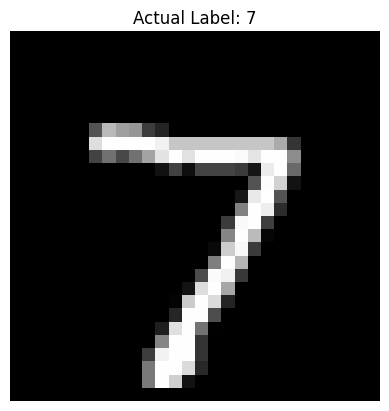

In [ ]:
plt.imshow(x_test[0], cmap="gray")
plt.title(f"Actual Label: {y_test[0]}")
plt.axis("off")
plt.show()

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
model = tf.keras.Sequential([
 # Flatten layer:
 # Converts 2D image (28x28) into 1D vector (784 values)
 layers.Flatten(input_shape=(28, 28)),
 # Dense layer:
 # Fully connected neural layer with 128 neurons
 # ReLU activation introduces non-linearity
 layers.Dense(128, activation='relu'),
 # Output layer:
 # 10 neurons (digits 0–9)
 # Softmax converts output into probabilities
 layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8700 - loss: 0.4618 - val_accuracy: 0.9655 - val_loss: 0.1234
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9620 - loss: 0.1328 - val_accuracy: 0.9727 - val_loss: 0.0984
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9734 - loss: 0.0872 - val_accuracy: 0.9747 - val_loss: 0.0888
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9809 - loss: 0.0622 - val_accuracy: 0.9767 - val_loss: 0.0831
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9864 - loss: 0.0436 - val_accuracy: 0.9760 - val_loss: 0.0827


In [ ]:
model.compile(
 optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy']
)

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9706 - loss: 0.0931
Test Accuracy: 0.9750000238418579


In [ ]:
image = x_test[0]
prediction = model.predict(image.reshape(1,28,28))
predicted_digit = np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


Digit 0: 0.0000
Digit 1: 0.0000
Digit 2: 0.0000
Digit 3: 0.0001
Digit 4: 0.0000
Digit 5: 0.0000
Digit 6: 0.0000
Digit 7: 0.9999
Digit 8: 0.0000
Digit 9: 0.0000


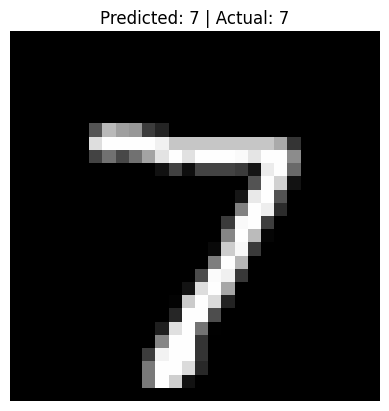

In [ ]:
for i, prob in enumerate(prediction[0]):
 print(f"Digit {i}: {prob:.4f}")
plt.imshow(image, cmap="gray")
plt.title(f"Predicted: {predicted_digit} | Actual: {y_test[0]}")
plt.axis("off")
plt.show()